# Assignment 3

## Classification Using Scikit Learn 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
import warnings
warnings.filterwarnings('ignore')

## Part 1: Data Exploration

### 1. Load the dataset and review its structure

In [2]:
df = pd.read_csv("Sumbal Zaheer - Employee.csv")

In [3]:
df

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [5]:
print("Shape of dataset:", df.shape)

Shape of dataset: (4653, 9)


In [6]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

In [7]:
categorical_features

['Education', 'City', 'Gender', 'EverBenched']

In [8]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features

['JoiningYear',
 'PaymentTier',
 'Age',
 'ExperienceInCurrentDomain',
 'LeaveOrNot']

In [9]:
cat_col = ['Education', 'City', 'Gender', 'EverBenched']

for colname in cat_col:
    df[colname] = df[colname].astype('category')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Education                  4653 non-null   category
 1   JoiningYear                4653 non-null   int64   
 2   City                       4653 non-null   category
 3   PaymentTier                4653 non-null   int64   
 4   Age                        4653 non-null   int64   
 5   Gender                     4653 non-null   category
 6   EverBenched                4653 non-null   category
 7   ExperienceInCurrentDomain  4653 non-null   int64   
 8   LeaveOrNot                 4653 non-null   int64   
dtypes: category(4), int64(5)
memory usage: 200.6 KB


### 3. Check for missing values.

In [11]:
df.isnull().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

### 4. Compute summary statistics for numerical features (Age, PaymentTier,
### ExperienceInCurrentDomain).

In [12]:
df[['Age', 'PaymentTier', 'ExperienceInCurrentDomain']].describe()

,Age,PaymentTier,ExperienceInCurrentDomain
count,4653.000000,4653.000000,4653.000000
mean,29.393295,2.698259,2.905652
std,4.826087,0.561435,1.558240
min,22.000000,1.000000,0.000000
25%,26.000000,3.000000,2.000000
50%,28.000000,3.000000,3.000000
75%,32.000000,3.000000,4.000000
max,41.000000,3.000000,7.000000


### 5. Analyze the distribution of categorical features (Education, City, Gender,
### EverBenched).

In [13]:
for col in categorical_features:
    print(f"\n{col} distribution:\n")
    print(df[col].value_counts())


Education distribution:

Education
Bachelors    3601
Masters       873
PHD           179
Name: count, dtype: int64

City distribution:

City
Bangalore    2228
Pune         1268
New Delhi    1157
Name: count, dtype: int64

Gender distribution:

Gender
Male      2778
Female    1875
Name: count, dtype: int64

EverBenched distribution:

EverBenched
No     4175
Yes     478
Name: count, dtype: int64


### 6. Plot or visualize the distribution of the target variable LeaveOrNot

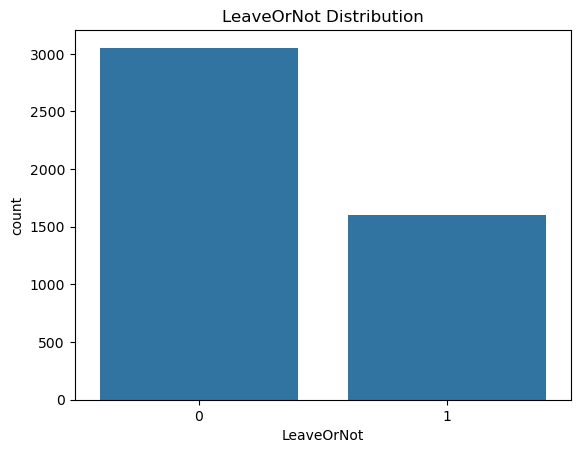

In [14]:
sns.countplot(x='LeaveOrNot', data=df)
plt.title("LeaveOrNot Distribution")
plt.show()

## Part 2: Data Preprocessing

### 1. Encode categorical features (Education, City, Gender, EverBenched) appropriately.

In [15]:
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

In [16]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   JoiningYear                4653 non-null   int64
 1   PaymentTier                4653 non-null   int64
 2   Age                        4653 non-null   int64
 3   ExperienceInCurrentDomain  4653 non-null   int64
 4   LeaveOrNot                 4653 non-null   int64
 5   Education_Masters          4653 non-null   bool 
 6   Education_PHD              4653 non-null   bool 
 7   City_New Delhi             4653 non-null   bool 
 8   City_Pune                  4653 non-null   bool 
 9   Gender_Male                4653 non-null   bool 
 10  EverBenched_Yes            4653 non-null   bool 
dtypes: bool(6), int64(5)
memory usage: 209.2 KB


In [17]:
df_encoded

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot,Education_Masters,Education_PHD,City_New Delhi,City_Pune,Gender_Male,EverBenched_Yes
0,2017,3,34,0,0,False,False,False,False,True,False
1,2013,1,28,3,1,False,False,False,True,False,False
2,2014,3,38,2,0,False,False,True,False,False,False
3,2016,3,27,5,1,True,False,False,False,True,False
4,2017,3,24,2,1,True,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...
4648,2013,3,26,4,0,False,False,False,False,False,False
4649,2013,2,37,2,1,True,False,False,True,True,False
4650,2018,3,27,5,1,True,False,True,False,True,False
4651,2012,3,30,2,0,False,False,False,False,True,True


In [18]:
df_encoded.shape

(4653, 11)

In [19]:
df_encoded.head()

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot,Education_Masters,Education_PHD,City_New Delhi,City_Pune,Gender_Male,EverBenched_Yes
0,2017,3,34,0,0,False,False,False,False,True,False
1,2013,1,28,3,1,False,False,False,True,False,False
2,2014,3,38,2,0,False,False,True,False,False,False
3,2016,3,27,5,1,True,False,False,False,True,False
4,2017,3,24,2,1,True,False,False,True,True,True


### 2. Handle scaling of numerical features if needed (Age, ExperienceInCurrentDomain,
### JoiningYear, PaymentTier).

In [20]:
# Split data to be used in the models
# Create matrix of features
x = df_encoded.drop('LeaveOrNot', axis=1)

# Create target variable
y = df_encoded['LeaveOrNot']

In [21]:
y.shape

(4653,)

In [22]:
x.shape

(4653, 10)

In [23]:
from sklearn import preprocessing
pre_process = preprocessing.StandardScaler().fit(x)
x_transform = pre_process.fit_transform(x)

In [24]:
x_transform

array([[ 1.03963837,  0.53750299,  0.95464513, ..., -0.61204068,
         0.82155097, -0.33836521],
       [-1.10723275, -3.0251771 , -0.28873172, ...,  1.63387832,
        -1.21720992, -0.33836521],
       [-0.57051497,  0.53750299,  1.78356303, ..., -0.61204068,
        -1.21720992, -0.33836521],
       ...,
       [ 1.57635615,  0.53750299, -0.49596119, ..., -0.61204068,
         0.82155097, -0.33836521],
       [-1.64395053,  0.53750299,  0.12572723, ..., -0.61204068,
         0.82155097,  2.95538654],
       [-0.03379719,  0.53750299,  0.74741565, ..., -0.61204068,
         0.82155097,  2.95538654]], shape=(4653, 10))

### 3. Split the dataset into training and testing sets (suggested: 80%-20%).

In [25]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = .20, random_state = 101)

In [26]:
x_train

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,Education_Masters,Education_PHD,City_New Delhi,City_Pune,Gender_Male,EverBenched_Yes
3150,2012,3,34,4,False,False,False,False,True,False
929,2012,3,28,2,True,False,True,False,True,False
657,2017,2,28,1,True,False,False,True,False,False
3124,2012,3,31,4,False,False,False,False,True,False
72,2014,3,25,3,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
4079,2014,3,33,4,False,False,False,True,True,False
4171,2017,2,26,4,True,False,True,False,True,False
599,2016,3,28,2,False,False,False,False,True,False
1361,2018,3,27,5,False,False,False,False,False,True


In [27]:
x_test

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,Education_Masters,Education_PHD,City_New Delhi,City_Pune,Gender_Male,EverBenched_Yes
2911,2013,3,28,1,False,False,True,False,False,False
2182,2017,3,29,2,False,False,False,False,True,False
497,2016,3,28,3,False,False,False,False,False,False
4283,2013,3,25,3,False,False,True,False,False,False
1661,2017,2,28,1,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
1739,2015,2,24,2,False,False,False,True,False,False
2352,2013,3,27,5,False,False,False,False,False,False
3264,2016,3,33,1,True,False,True,False,False,False
3172,2015,3,32,4,False,False,False,False,True,False


In [28]:
y_test

2911    0
2182    0
497     0
4283    0
1661    0
       ..
1739    1
2352    0
3264    0
3172    0
1763    0
Name: LeaveOrNot, Length: 931, dtype: int64

In [29]:
y_train

3150    0
929     0
657     0
3124    0
72      0
       ..
4079    0
4171    0
599     0
1361    1
1547    1
Name: LeaveOrNot, Length: 3722, dtype: int64

## Part 3 & 4: Model Building And Model Evaluation

### 1. Decision Tree Classifier

#### Model Training

In [30]:
from sklearn.tree import DecisionTreeClassifier

print('Decision Tree Classifier')
# create instance of model
Dtree = DecisionTreeClassifier(random_state=42)

# pass training data into model
Dtree.fit(x_train, y_train)

Decision Tree Classifier


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### Model Evaluation

In [31]:
from sklearn.metrics import accuracy_score
# prediction from the model
y_pred_Dtree = Dtree.predict(x_test)
# Score It

print('Decision tree classifier')
# Accuracy
print('--'*30)
Dtree_Accuracy = round(accuracy_score(y_test, y_pred_Dtree) * 100,2)
print('Accuracy',Dtree_Accuracy ,'%')

Decision tree classifier
------------------------------------------------------------
Accuracy 81.31 %


#### The Decision Tree Classifier achieved an accuracy of 81.31%.
#### The model predicts employee attrition by creating decision rules based on features.
#### It is simple and easy to interpret but may suffer from overfitting.

### 2. Random Forest Classifier

#### Model Training

In [32]:
from sklearn.ensemble import RandomForestClassifier

print('Random forset classifier')

rfc = RandomForestClassifier(random_state=42)
rfc.fit(x_train, y_train)

Random forset classifier


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Model Evaluation

In [33]:
from sklearn.metrics import accuracy_score
# prediction from the model
y_pred_rfc = rfc.predict(x_test)
# Score It

print('Random forset Accuracy')
# Accuracy
print('--'*30)
rfc_Accuracy = round(accuracy_score(y_test, y_pred_rfc) * 100,2)
print('Accuracy',rfc_Accuracy ,'%')

Random forset Accuracy
------------------------------------------------------------
Accuracy 83.03 %


#### The Random Forest Classifier achieved an accuracy of 83.03%.
#### It performed better than Decision Tree because it combines multiple trees and reduces overfitting.
#### The model provides more stable and accurate predictions.

### 3. Logistic Regression

#### Model Training

In [34]:
from sklearn.linear_model import LogisticRegression

print('Logistic Regression')
# Create instance of model
log_reg = LogisticRegression()

# Pass training data into model
log_reg.fit(x_train, y_train)

Logistic Regression


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


#### Model Evaluation

In [35]:
from sklearn.metrics import accuracy_score
# prediction from the model
y_pred_log_reg = log_reg.predict(x_test)
# Score It

print('Logistic Regression')
# Accuracy
print('--'*30)
log_reg_accuracy = round(accuracy_score(y_test, y_pred_log_reg) * 100,2)
print('Accuracy', log_reg_accuracy,'%')

Logistic Regression
------------------------------------------------------------
Accuracy 76.26 %


#### The Logistic Regression model achieved an accuracy of 76.26%.
#### It performed lower than the other models because it assumes a linear relationship between features and the target variable.
#### However, it is simple, fast, and useful for basic classification tasks.

### 4. Gradient Boosting Classifier

#### Model Training

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

print('Gradient Boosting Classifier')
# Create instance of model
gbc = GradientBoostingClassifier(random_state=42)

# Pass training data into model
gbc.fit(x_train, y_train)

Gradient Boosting Classifier


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


#### Model Evaluation

In [37]:
from sklearn.metrics import accuracy_score
# prediction from the model
y_pred_gbc = gbc.predict(x_test)
# Score It

print('Random forset Accuracy')
# Accuracy
print('--'*30)
gbc_Accuracy = round(accuracy_score(y_test, y_pred_gbc) * 100,2)
print('Accuracy',gbc_Accuracy ,'%')

Random forset Accuracy
------------------------------------------------------------
Accuracy 85.39 %


#### The Gradient Boosting Classifier achieved an accuracy of 85.39%.
#### It gave the highest accuracy among all models.
#### This model improves prediction performance by correcting previous model errors step by step.

In [38]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Decision Tree": y_pred_Dtree,
    "Random Forest": y_pred_rfc,
    "Gradient Boosting": y_pred_gbc,
    "Logistic Regression": y_pred_log_reg
})

print(comparison_df.head(20))

    Actual  Decision Tree  Random Forest  Gradient Boosting  \
0        0              0              0                  0   
1        0              0              0                  0   
2        0              0              0                  0   
3        0              0              0                  0   
4        0              1              1                  0   
5        0              0              0                  0   
6        0              0              1                  0   
7        0              0              0                  0   
8        0              0              0                  0   
9        0              0              0                  0   
10       0              0              0                  0   
11       1              0              0                  0   
12       0              0              0                  0   
13       0              0              0                  0   
14       0              0              0               

In [39]:
model_scores = {
    'Logistic Regression': log_reg_accuracy,
    'Decision Tree Classifier': Dtree_Accuracy,
    'Random Forest Classifier': rfc_Accuracy,
    'Gradiant Boosting Classifier': gbc_Accuracy
}

sorted_scores = sorted(model_scores.items(), key=lambda x: x[1], reverse=True)

print('Model Rankings (Greater values are better):')
for rank, (model_name, score) in enumerate(sorted_scores, start=1):
    print(f'{rank}. {model_name} : {score}')

Model Rankings (Greater values are better):
1. Gradiant Boosting Classifier : 85.39
2. Random Forest Classifier : 83.03
3. Decision Tree Classifier : 81.31
4. Logistic Regression : 76.26


#### Among all models, Gradient Boosting achieved the highest accuracy of 85.39%, making it the best-performing model.
#### Random Forest also performed well with 83.03% accuracy because it combines multiple decision trees and reduces overfitting.
#### Decision Tree achieved 81.31% accuracy but may overfit the training data.
#### Logistic Regression gave the lowest accuracy of 76.26% because employee attrition patterns are likely non-linear.

## Part 5: Analysis Questions and Answers

#### 1. Which features are most important in predicting employee attrition?

In [40]:
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rfc.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

                     Feature  Importance
0                JoiningYear    0.335241
2                        Age    0.164857
1                PaymentTier    0.100643
8                Gender_Male    0.090637
4          Education_Masters    0.084472
3  ExperienceInCurrentDomain    0.081241
7                  City_Pune    0.079073
6             City_New Delhi    0.031443
9            EverBenched_Yes    0.022016
5              Education_PHD    0.010378


#### Based on the Random Forest model, the most important features in predicting employee attrition are JoiningYear, Age, and PaymentTier.
#### JoiningYear is the strongest predictor, followed by Age and PaymentTier, indicating that employee tenure and career stage play a major role in attrition.

### **2. How do Age and ExperienceInCurrentDomain affect the likelihood of leaving?**

#### Age and ExperienceInCurrentDomain have a noticeable effect on employee attrition.
#### The feature importance shows that Age has a moderate impact, while ExperienceInCurrentDomain has
#### a lower importance compared to other features. This indicates that younger employees and those with less experience
#### are slightly more likely to leave the company compared to older and more experienced employees, although these factors
#### are not the strongest predictors.

### **3. Compare Decision Tree and Random Forest results. Which model performs better and why?**

#### The Decision Tree model achieved an accuracy of 81.31%, while the Random Forest model achieved a higher accuracy of 82.81%.
#### Random Forest performed better because it combines multiple decision trees and reduces overfitting, making it more stable
#### and accurate compared to a single Decision Tree, which is more prone to overfitting on training data.

### **4. Suggest HR strategies based on your analysis.**

#### Based on the analysis, the company should focus on improving employee retention strategies by targeting key
#### factors such as employee tenure, salary structure, and career growth opportunities.
#### Since JoiningYear and Age are important factors, HR should focus on onboarding experience and engagement of new employees.
#### Training programs, better promotion opportunities, and competitive compensation packages can help reduce employee attrition,
#### especially among younger and less experienced employees.